### TUNE SHIFT ANALYSIS

- Finds the tune of the bpm motion through naff
- finds spectral harmonics


In [1]:
import numpy as np
from nafflib import naff, fundamental_frequency, tune

import matplotlib.pyplot as plt
from tools.open_h5 import open_file, print_tree
from tools.centroid_motion import rss_position_from_delta_sigma, std_position_from_delta_sigma, find_peak_and_dip
from tools.frequency_finder import main_frequency
from tools.split_dataset import split_data


In [2]:
file = '/Volumes/RFS/Wakes and Space Charge/cern/sps/2018_10_TMCImeasurements/headtail/2018_11_09/SPS.BQHT_MD4_20181109_000915.h5'

In [3]:
print_tree(file)
vert_delta, vert_sigma, horiz_delta, horiz_sigma = open_file(file)

|-- horizontal
  |-- delta
  |-- sigma
|-- vertical
  |-- delta
  |-- sigma


In [4]:
total_l = len(vert_delta)
f = main_frequency(vert_delta, 1)
period = int(np.ceil(1/f))
print(period)

1000


In [5]:
# vert_sigma_split = split_data(vert_sigma, period=period)
# plt.figure(figsize=(12,6))
# plt.plot(vert_sigma_split[1000,:])

### CALCULATE TUNES

In [6]:
tune(vert_sigma- np.average(vert_sigma))

np.float64(0.009999999995890772)

In [7]:
tune(vert_delta- np.average(vert_delta)) 

np.float64(0.00999999983705711)

In [8]:
tune(horiz_delta- np.average(horiz_delta)) 

np.float64(0.013000006900494708)

In [9]:
tune(horiz_sigma-np.average(horiz_sigma))

np.float64(0.009999999995890772)

### COMPARE SPECTRUM AT DIFFERENT POINTS DURING SAMPLING

In [10]:
direction = 'vertical'

if direction == 'vertical':
    signal_d = vert_delta
    signal_s = vert_sigma
else:
    signal_d = horiz_delta
    signal_s = horiz_sigma

In [11]:
#STARTING TURN A, END TURN B    
a = 0
b = 100

arr = (signal_d[a*period:b*period]- np.average(signal_d[a*period:b*period]))#/(horiz_sigma[a*period:b*period]-np.average(horiz_sigma[a*period:b*period]))
ampl, freq = naff(arr.astype(complex),num_harmonics=18)

fft_x = np.fft.fftfreq(len(arr))
fft_z = np.fft.fft(arr)


In [12]:
a = 4000
b = 4100

arr = (signal_d[a*period:b*period]- np.average(signal_d[a*period:b*period]))#/(horiz_sigma[a*period:b*period]-np.average(horiz_sigma[a*period:b*period]))
ampl_2, freq_2 = naff(arr.astype(complex),num_harmonics=18)

fft_x_2 = np.fft.fftfreq(len(arr))
fft_z_2 = np.fft.fft(arr)


/opt/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


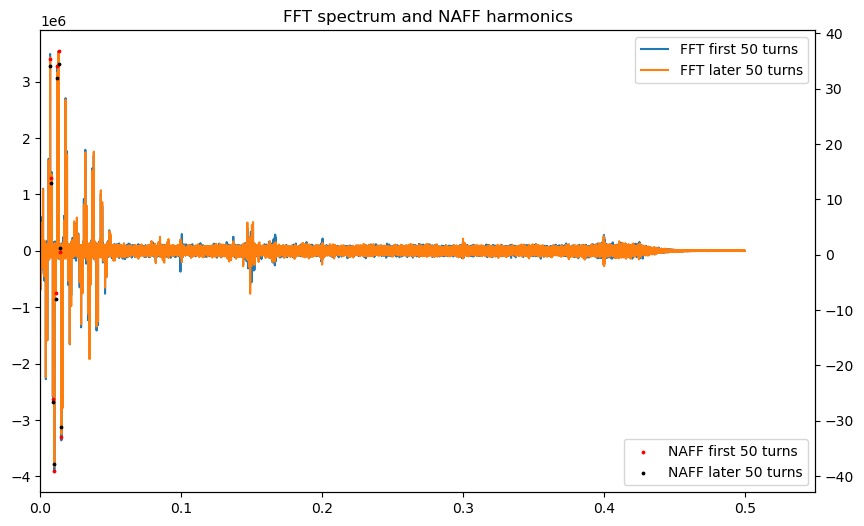

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('FFT spectrum and NAFF harmonics')
ax.plot(fft_x, fft_z, label ='FFT first 50 turns')
ax.plot(fft_x_2, fft_z_2, label ='FFT later 50 turns')
ax.legend(loc='upper right')
ax2 = ax.twinx()
ax2.scatter(freq, ampl.real, c='r', s = 3, label = 'NAFF first 50 turns')
ax2.scatter(freq_2, ampl_2.real, c='k', s = 3, label = 'NAFF later 50 turns')
ax2.legend(loc='lower right')
plt.xlim(0)
plt.show()